<a href="https://colab.research.google.com/github/Clovis4566/TECH-TALENT-ACCELERATOR/blob/main/Mon_exercice_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installation du modèle linguistique en anglais pour spaCy
!python -m spacy download en_core_web_sm

# Téléchargement des ressources essentielles pour NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [7]:
listes_livres = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
 ]

In [8]:
import requests
import re

In [9]:
def load_texts(liste_des_urls):
    # 1. On crée une boîte vide (une liste) pour stocker nos futurs textes propres
    corpus = []

    # 2. On fait une boucle : pour chaque URL de notre liste, on va faire le travail
    for url in liste_des_urls:

        # A. Le robot télécharge le texte brut depuis internet
        texte_brut = requests.get(url).text

        # B. On cherche où commence et où finit l'histoire pour couper le texte légal
        debut = texte_brut.find("*** START OF THE PROJECT GUTENBERG")
        fin = texte_brut.find("*** END OF THE PROJECT GUTENBERG")

        # On découpe le texte pour ne garder que le milieu
        texte_coupe = texte_brut[debut:fin]

        # C. C'est ici qu'on nettoie !
        # On remplace tout ce qui n'est pas une lettre ([^a-zA-Z\s]) par un vide ""
        texte_propre = re.sub(r'[^a-zA-Z\s]', '', texte_coupe)

        # D. On ajoute ce texte propre dans notre boîte "corpus"
        corpus.append(texte_propre)

    # 3. Quand la boucle est finie, la fonction nous donne la boîte pleine
    return corpus

In [6]:
mes_textes_propres = load_texts(listes_livres)

In [10]:
# On donne des titres à nos livres pour s'y retrouver
titres = ["Alice au pays des merveilles", "De l'autre côté du miroir", "Une histoire complexe"]

# On fait une boucle pour afficher le début de chaque texte
for i in range(3):
    print(f"--- Livre : {titres[i]} ---")
    # On affiche les 200 premiers caractères du texte propre
    print(mes_textes_propres[i][:200])
    print("\n" + "="*40 + "\n")

--- Livre : Alice au pays des merveilles ---
 START OF THE PROJECT GUTENBERG EBOOK ALICES ADVENTURES IN WONDERLAND 

Illustration




Alices Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 

Contents

 C


--- Livre : De l'autre côté du miroir ---
 START OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKINGGLASS 

Illustration




THROUGH THE LOOKINGGLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edition 



--- Livre : Une histoire complexe ---
 START OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE 




Produced by Chris Curnow Carla Foust Lindy Walsh and the
Online Distributed Proofreading Team at httpswwwpgdpnet
Music transcribed by L




In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
from nltk.tokenize import word_tokenize

# On crée une liste vide pour stocker nos listes de mots
corpus_tokens = []

for texte in mes_textes_propres:
    # On passe le texte en minuscules (.lower()) pour que "Alice" et "alice" soient le même mot
    texte_minuscule = texte.lower()

    # On découpe le texte en mots
    mots = word_tokenize(texte_minuscule)

    # On ajoute la liste de mots à notre corpus
    corpus_tokens.append(mots)

# Maintenant, on affiche les 150 premiers mots de chaque livre
for i in range(3):
    print(f"--- 150 premiers mots de : {titres[i]} ---")
    print(corpus_tokens[i][:150])
    print("\n" + "="*40 + "\n")

--- 150 premiers mots de : Alice au pays des merveilles ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alices', 'adventures', 'in', 'wonderland', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbithole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucusrace', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'teaparty', 'chapter', 'viii', 'the', 'queens', 'croquetground', 'chapter', 'ix', 'the', 'mock', 'turtles', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alices', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbithole', 'alice', 'was', 'beginning', 'to', 'get', 'very

In [14]:
from nltk.corpus import stopwords

# 1. On récupère la liste des mots vides anglais
mots_vides_anglais = set(stopwords.words('english'))

# 2. On crée une liste pour stocker nos textes filtrés
corpus_sans_mots_vides = []

for liste_mots in corpus_tokens:
    # On garde le mot UNIQUEMENT s'il n'est pas dans la liste des mots vides
    mots_filtres = [mot for mot in liste_mots if mot not in mots_vides_anglais]
    corpus_sans_mots_vides.append(mots_filtres)

# 3. VÉRIFICATION (comme demandé dans la consigne)
# On va compter combien de fois il reste les mots "i", "me", "my" dans nos livres
mots_a_verifier = ["i", "me", "my", "myself", "we"]

for i in range(3):
    print(f"--- Vérification pour : {titres[i]} ---")

    # Pour chaque mot à vérifier, on compte sa présence dans notre texte filtré
    for mot in mots_a_verifier:
        nombre_de_fois = corpus_sans_mots_vides[i].count(mot)
        print(f"Le mot '{mot}' apparaît : {nombre_de_fois} fois.")
    print("\n")

--- Vérification pour : Alice au pays des merveilles ---
Le mot 'i' apparaît : 0 fois.
Le mot 'me' apparaît : 0 fois.
Le mot 'my' apparaît : 0 fois.
Le mot 'myself' apparaît : 0 fois.
Le mot 'we' apparaît : 0 fois.


--- Vérification pour : De l'autre côté du miroir ---
Le mot 'i' apparaît : 0 fois.
Le mot 'me' apparaît : 0 fois.
Le mot 'my' apparaît : 0 fois.
Le mot 'myself' apparaît : 0 fois.
Le mot 'we' apparaît : 0 fois.


--- Vérification pour : Une histoire complexe ---
Le mot 'i' apparaît : 0 fois.
Le mot 'me' apparaît : 0 fois.
Le mot 'my' apparaît : 0 fois.
Le mot 'myself' apparaît : 0 fois.
Le mot 'we' apparaît : 0 fois.




In [15]:
from nltk.stem import PorterStemmer

# On initialise le robot de racinisation
stemmer = PorterStemmer()

corpus_stemmed = []

for liste_mots in corpus_sans_mots_vides:
    # On applique le stemmer sur chaque mot
    mots_racines = [stemmer.stem(mot) for mot in liste_mots]
    corpus_stemmed.append(mots_racines)

# Affichons les 50 premiers tokens racinisés du premier livre
print("--- 50 premiers tokens après Stemming (Alice) ---")
print(corpus_stemmed[0][:50])

--- 50 premiers tokens après Stemming (Alice) ---
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground']


In [16]:
import spacy

# On charge le modèle linguistique anglais de spaCy
nlp = spacy.load("en_core_web_sm")

corpus_lemmatized = []

for texte in mes_textes_propres:
    # spaCy analyse le texte complet (on limite aux 40 000 premiers caractères pour que ça aille vite)
    doc = nlp(texte[:40000])

    # On récupère le lemme de chaque mot, en ignorant les espaces ou la ponctuation restante
    mots_lemmes = [token.lemma_.lower() for token in doc if not token.is_space and not token.is_punct]
    corpus_lemmatized.append(mots_lemmes)

# Affichons les 50 premiers tokens lemmatisés du premier livre
print("--- 50 premiers tokens après Lemmatisation (Alice) ---")
print(corpus_lemmatized[0][:50])

--- 50 premiers tokens après Lemmatisation (Alice) ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alices', 'adventures', 'in', 'wonderland', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'i', 'down', 'the', 'rabbithole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucusrace', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'send', 'in', 'a', 'little']


📝 Ce qu'il faut répondre pour la Question 7 :
Le Stemming (Racinisation) : Il coupe brutalement les mots selon des règles fixes (par exemple, enlever les suffixes comme -ing, -ed, -s). C'est très rapide, mais le résultat donne souvent des non-mots (comme alices qui devient alic, ou adventures qui devient adventur).

La Lemmatisation (spaCy) : Elle est beaucoup plus intelligente. Elle s'appuie sur un dictionnaire et une analyse de la grammaire. Elle ramène chaque mot à sa forme de base "officielle". Par exemple, le verbe sends ou sending devient send (comme on le voit à la fin de ta liste : 'the', 'rabbit', 'send', 'in'), et was deviendra be. Le résultat donne toujours de vrais mots compréhensibles.

In [18]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [20]:
import nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [21]:
import nltk

print("--- Question 8 : Étiquettes POS (Grammaire) ---")
# On prend les 10 premiers mots du livre d'Alice pour voir leur nature
mots_exemple = corpus_tokens[0][:10]
tags_pos = nltk.pos_tag(mots_exemple)
print(tags_pos)

print("\n--- Question 9 : Identification des Entités ---")
# Le Chunker de NLTK repère les noms propres, lieux, etc.
entites = nltk.ne_chunk(tags_pos)
print(entites)


--- Question 8 : Étiquettes POS (Grammaire) ---
[('start', 'NN'), ('of', 'IN'), ('the', 'DT'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('in', 'IN'), ('wonderland', 'NN')]

--- Question 9 : Identification des Entités ---
(S
  start/NN
  of/IN
  the/DT
  project/NN
  gutenberg/NN
  ebook/NN
  alices/NNS
  adventures/VBZ
  in/IN
  wonderland/NN)


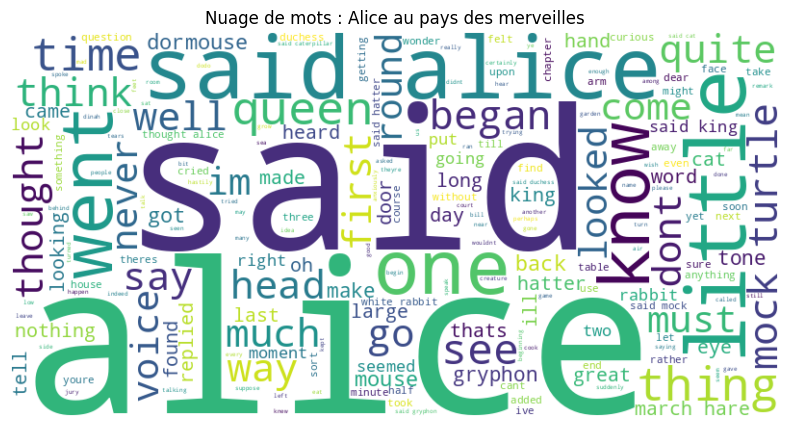

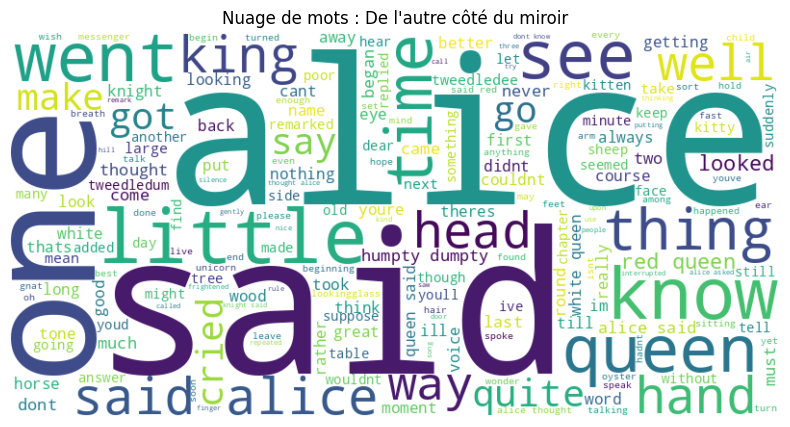

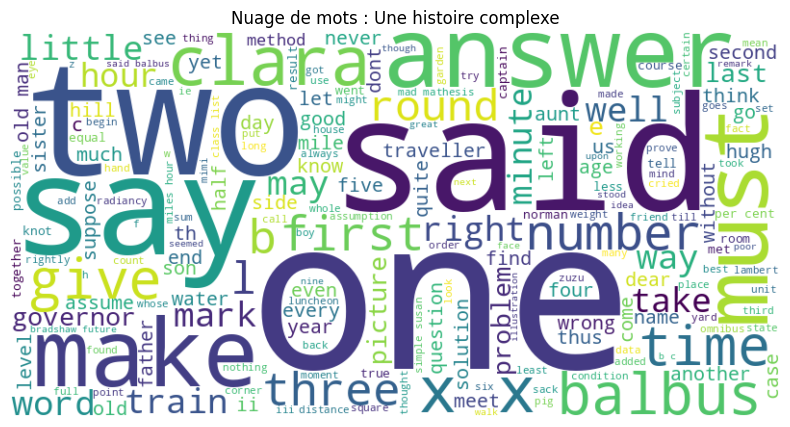

In [22]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# On boucle sur nos 3 livres pour afficher un nuage de mots pour chacun
for i in range(3):
    # WordCloud a besoin d'un gros texte (une seule chaîne), pas d'une liste de mots.
    # On rassemble donc nos mots filtrés avec un espace entre chaque grâce à " ".join()
    texte_pour_nuage = " ".join(corpus_sans_mots_vides[i])

    # On génère le nuage de mots
    nuage = WordCloud(width=800, height=400, background_color='white').generate(texte_pour_nuage)

    # On l'affiche avec Matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(nuage, interpolation='bilinear')
    plt.title(f"Nuage de mots : {titres[i]}")
    plt.axis('off') # On cache les axes (les chiffres autour de l'image)
    plt.show()